In [1]:
import numpy as np
from cq.numeric import *

D = 3
n = 2000
gs, Ts = [], []
T_matrix = T_matrix(D)
for _ in range(n):
    v, w = rand_ortho_pair(D+1)
    rho = np.outer(v, v) + np.outer(w, w)
    T = (rho @ T_matrix).trace()
    g = rho_to_g(rho)
    Ts.append(T)
    gs.append(g)
gs, Ts = np.array(gs), np.array(Ts)

In [2]:
X = np.column_stack([gs[:,1:], Ts]) #remove g_0 to avoid bias ruining implicit polynomial fit
X_train, X_test = X[:n//2], X[-n//2:]

In [3]:
from sklearn.preprocessing import PolynomialFeatures

#ChatGPT do your thing
class ImplicitPolynomial:
    def __init__(self, degree: int):
        self.degree = degree
        self.features = PolynomialFeatures(
            degree=degree,
            include_bias=True,
        )

    def fit(self, xyz: np.ndarray) -> "ImplicitPolynomial":
        """
        Fit p(x, y, z) = 0 to points of shape (n_samples, 7).
        """
        xyz = np.asarray(xyz, dtype=float)

        if xyz.ndim != 2 or xyz.shape[1] != 7:
            raise ValueError("xyz must have shape (n_samples, 7)")

        # Design matrix:
        # [1, x, y, z, x², xy, xz, y², yz, z², ...]
        A = self.features.fit_transform(xyz)

        # Solve min ||A c|| subject to ||c|| = 1.
        _, singular_values, Vt = np.linalg.svd(A, full_matrices=False)

        self.coef_ = Vt[-1]
        self.singular_values_ = singular_values
        return self

    def predict(self, xyz: np.ndarray) -> np.ndarray:
        """
        Evaluate p(x, y, z). Points on the fitted surface give values near zero.
        """
        A = self.features.transform(np.asarray(xyz, dtype=float))
        return A @ self.coef_

    def equation(self, precision: int = 5) -> str:
        names = self.features.get_feature_names_out(['g1', 'g2', 'g3', 'g4', 'g5', 'g6', 'T'])

        terms = [
            f"{coef:+.{precision}g}*{name}"
            for coef, name in zip(self.coef_, names)
            if abs(coef) > 10 ** (-precision)
        ]
        return " ".join(terms) + " = 0"

p = ImplicitPolynomial(3)
#errors at degrees
#1: 0.025755734361205623
#2: 0.0003061402633815249
#3: 1.270077377801504e-26
p.fit(X_train)
np.var(p.predict(X_test))

np.float64(6.223878519958007e-27)

In [4]:
p.equation(2)

'-0.46*g1 +0.42*g3 -0.081*g5 +0.12*g1 g2 +0.03*g1 g4 -0.21*g1 g6 +0.36*g1 T -0.27*g2 g3 +0.32*g2 g5 +0.084*g3 g4 +0.16*g3 g6 -0.23*g3 T -0.21*g4 g5 +0.028*g5 g6 -0.12*g5 T -0.012*g1^2 g3 +0.034*g1 g2^2 -0.095*g1 g2 g4 +0.074*g1 g2 g6 -0.057*g1 g2 T +0.012*g1 g3^2 -0.016*g1 g3 g5 +0.054*g1 g4^2 -0.054*g1 g4 g6 -0.016*g1 g4 T +0.09*g1 g6 T -0.06*g1 T^2 +0.017*g2^2 g3 -0.043*g2^2 g5 -0.058*g2 g3 g6 +0.11*g2 g3 T +0.053*g2 g4 g5 +0.032*g2 g5 g6 -0.14*g2 g5 T -0.016*g3 g4^2 +0.039*g3 g4 g6 -0.02*g3 g4 T -0.062*g3 g6 T -0.015*g4^2 g5 -0.024*g4 g5 g6 +0.09*g4 g5 T -0.036*g5 g6 T +0.088*g5 T^2 = 0'

In [5]:
import sympy as sp

#ChatGPT do your thing
def to_sympy(model, variable_names=None, float_precision=None):
    """
    Convert a fitted ImplicitPolynomial model to a SymPy polynomial.

    Returns
    -------
    expr : sympy.Expr
        The polynomial expression p(x0, ..., x6).
    poly : sympy.Poly
        The same expression as a multivariate SymPy polynomial.
    symbols : tuple[sympy.Symbol, ...]
        The polynomial variables.
    """
    if not hasattr(model, "coef_"):
        raise ValueError("The model must be fitted first.")

    n_variables = model.features.n_features_in_

    if variable_names is None:
        variable_names = [f"x{i}" for i in range(n_variables)]

    if len(variable_names) != n_variables:
        raise ValueError(
            f"Expected {n_variables} variable names, "
            f"got {len(variable_names)}."
        )

    symbols = sp.symbols(" ".join(variable_names))

    expr = sp.Integer(0)

    for coefficient, powers in zip(
        model.coef_,
        model.features.powers_,
    ):
        if float_precision is None:
            coefficient_sympy = sp.Float(coefficient)
        else:
            coefficient_sympy = sp.Float(
                coefficient,
                float_precision,
            )

        monomial = sp.prod(
            symbol ** int(power)
            for symbol, power in zip(symbols, powers)
        )

        expr += coefficient_sympy * monomial

    expr = sp.expand(expr)
    poly = sp.Poly(expr, *symbols)

    return expr, poly, symbols

expr, poly, variables = to_sympy(
    p,
    variable_names=[
        'g1', 'g2', 'g3', 'g4', 'g5', 'g6', 'T'
    ],
)

display(poly)

Poly(0.00334425770154262*g1**3 - 2.44942954807925e-14*g1**2*g2 - 0.0116049436610103*g1**2*g3 + 7.69523333943312e-14*g1**2*g4 + 0.00854805177920454*g1**2*g5 - 8.61203469648686e-14*g1**2*g6 + 7.72784614078148e-14*g1**2*T - 2.35791854791279e-13*g1**2 + 0.0342786414412304*g1*g2**2 - 2.91051904799389e-14*g1*g2*g3 - 0.0946095961282112*g1*g2*g4 + 8.40993941153556e-14*g1*g2*g5 + 0.0740282999369966*g1*g2*g6 - 0.0567539351719973*g1*g2*T + 0.120602112240477*g1*g2 + 0.0117049019554682*g1*g3**2 - 9.75608482889356e-14*g1*g3*g4 - 0.0164515726209703*g1*g3*g5 + 1.48835804791858e-13*g1*g3*g6 - 1.02973185533983e-13*g1*g3*T + 4.71126609946637e-13*g1*g3 + 0.053508123225355*g1*g4**2 - 1.72084568816899e-15*g1*g4*g5 - 0.0537306111838974*g1*g4*g6 - 0.0163834498743433*g1*g4*T + 0.0300363247696228*g1*g4 + 0.00535081232251943*g1*g5**2 - 5.20833376427277e-14*g1*g5*g6 + 1.8249290967276e-15*g1*g5*T - 2.3288055511772e-13*g1*g5 - 0.00535081232250748*g1*g6**2 + 0.0897358506600987*g1*g6*T - 0.206392456518375*g1*g6 - 0.0

In [6]:
#filter coefficients
poly = sp.Poly.from_dict(
    {k:v for k, v in poly.as_dict().items() if abs(float(v))>1e-10},
    *poly.gens
)
poly

Poly(0.00334425770154262*g1**3 - 0.0116049436610103*g1**2*g3 + 0.00854805177920454*g1**2*g5 + 0.0342786414412304*g1*g2**2 - 0.0946095961282112*g1*g2*g4 + 0.0740282999369966*g1*g2*g6 - 0.0567539351719973*g1*g2*T + 0.120602112240477*g1*g2 + 0.0117049019554682*g1*g3**2 - 0.0164515726209703*g1*g3*g5 + 0.053508123225355*g1*g4**2 - 0.0537306111838974*g1*g4*g6 - 0.0163834498743433*g1*g4*T + 0.0300363247696228*g1*g4 + 0.00535081232251943*g1*g5**2 - 0.00535081232250748*g1*g6**2 + 0.0897358506600987*g1*g6*T - 0.206392456518375*g1*g6 - 0.0601966386285583*g1*T**2 + 0.361179831771543*g1*T - 0.459835433968484*g1 + 0.0170660936193076*g2**2*g3 - 0.0433508340233595*g2**2*g5 + 0.00709424189644618*g2*g3*g4 - 0.0582851447264855*g2*g3*g6 + 0.110056060802317*g2*g3*T - 0.269347727753056*g2*g3 + 0.0528773570978472*g2*g4*g5 + 0.0320514141985399*g2*g5*g6 - 0.139884347343565*g2*g5*T + 0.316898490586993*g2*g5 - 0.00341321872383854*g3**3 + 0.00732690152504901*g3**2*g5 - 0.0163834498745029*g3*g4**2 + 0.038885535286

In [7]:
poly = sp.Poly(poly, sp.Symbol('T'))
poly

Poly((-0.0601966386285583*g1 + 0.0879228183011524*g5)*T**2 + (-0.0567539351719973*g1*g2 - 0.0163834498743433*g1*g4 + 0.0897358506600987*g1*g6 + 0.361179831771543*g1 + 0.110056060802317*g2*g3 - 0.139884347343565*g2*g5 - 0.020065546209598*g3*g4 - 0.0622786629629512*g3*g6 - 0.22936829824303*g3 + 0.089735850660267*g4*g5 - 0.0360435897240958*g5*g6 - 0.117230424401979*g5)*T + 0.00334425770154262*g1**3 - 0.0116049436610103*g1**2*g3 + 0.00854805177920454*g1**2*g5 + 0.0342786414412304*g1*g2**2 - 0.0946095961282112*g1*g2*g4 + 0.0740282999369966*g1*g2*g6 + 0.120602112240477*g1*g2 + 0.0117049019554682*g1*g3**2 - 0.0164515726209703*g1*g3*g5 + 0.053508123225355*g1*g4**2 - 0.0537306111838974*g1*g4*g6 + 0.0300363247696228*g1*g4 + 0.00535081232251943*g1*g5**2 - 0.00535081232250748*g1*g6**2 - 0.206392456518375*g1*g6 - 0.459835433968484*g1 + 0.0170660936193076*g2**2*g3 - 0.0433508340233595*g2**2*g5 + 0.00709424189644618*g2*g3*g4 - 0.0582851447264855*g2*g3*g6 - 0.269347727753056*g2*g3 + 0.0528773570978472

In [8]:
from itertools import islice

for g, T in islice(zip(gs, Ts), 10):
    print(poly.subs({sp.Symbol('g1'): g[1],
                     sp.Symbol('g2'): g[2],
                     sp.Symbol('g3'): g[3],
                     sp.Symbol('g4'): g[4],
                     sp.Symbol('g5'): g[5],
                     sp.Symbol('g6'): g[6],
                     sp.Symbol('T'): T}))

1.52072798798031e-12
-5.43341955629162e-14
-2.46615878760070e-13
6.36907193651837e-13
-7.76800498925034e-13
-1.03606012658020e-12
4.59507432104544e-13
-2.38711828082216e-13
7.78873222428283e-13
-6.61762311615632e-14


---

  0%|          | 0/1000 [00:00<?, ?it/s]

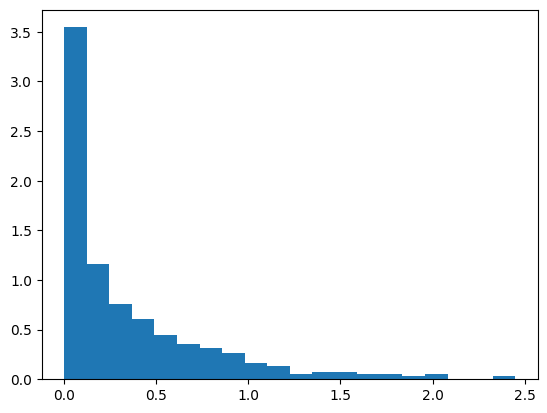

In [9]:
from cq.symbolic import vecabsq
import matplotlib.pyplot as plt
from tqdm.notebook import trange

norms = []
for i in trange(1000):
    g = gs[-i]
    tmp = sp.Poly(poly.subs({sp.Symbol(f'g{j}'):g[j] for j in range(len(g))}), sp.Symbol('T'))
    norms.append(float(vecabsq(tmp.as_list())))

plt.hist(norms, density=True, bins=20)
plt.show()